In [ ]:
!pip install gymnasium[box2d]
!pip install stable-baselines3
!pip install swig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 11.9 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("LunarLander-v3")


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/

In [ ]:
# At each time step, the agent selects an action uniformly at random.
# This provides a reference point to compare against the learned policy.
def run_random_policy(env, n_episodes=5):
    for episode in range(n_episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

        print(f"Episode {episode+1}: total reward = {total_reward}")
#“This baseline shows that without learning, the agent obtains highly negative and unstable rewards.”

In [ ]:
run_random_policy(env)
#Episode rewards: highly negative and unstable rewards

Episode 1: total reward = -156.24251949174334
Episode 2: total reward = -385.3097737438142
Episode 3: total reward = -317.7355147613182
Episode 4: total reward = -365.8475523519915
Episode 5: total reward = -7.334349694848825


In [ ]:
# We initialize a PPO agent using a multilayer perceptron (MLP) policy.
# PPO is treated as a black-box algorithm as required by the TP instructions.
# The discount factor gamma controls the importance of future rewards.

model = PPO(
    policy="MlpPolicy",
    env=env,
    gamma=0.99,  # discount factor γ (lecture notation)
    verbose=1
)
# First training phase: 10,000 time steps.
# This short training allows us to observe early learning behavior.
model.learn(total_timesteps=10_000)


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 103      |
|    ep_rew_mean     | -234     |
| time/              |          |
|    fps             | 859      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 103          |
|    ep_rew_mean          | -212         |
| time/                   |              |
|    fps                  | 714          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0054496983 |
|    clip_fraction        | 0.0222       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance   | 0.0022       |
|    learning_rate        | 0.0003       |
|    loss                 | 507          |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00478     |
|    value_loss           | 1.54e+03     |
------------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mea

In [ ]:
# We visualize the learned policy by running one episode
# using deterministic actions selected by the trained model.
# Rendering allows us to qualitatively assess the agent’s behavior.

eval_env = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []
state, _ = eval_env.reset()

for _ in range(500):
    action, _ = model.predict(state, deterministic=True)
    state, _, terminated, truncated, _ = eval_env.step(action)
    frames.append(eval_env.render())
    if terminated or truncated:
        break


In [ ]:
# We continue training the same agent for an additional 50,000 steps.
# This allows the policy to further improve through more experience.
model.learn(total_timesteps=50_000)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 115      |
|    ep_rew_mean     | -122     |
| time/              |          |
|    fps             | 635      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 123         |
|    ep_rew_mean          | -102        |
| time/                   |             |
|    fps                  | 536         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011113491 |
|    clip_fraction        | 0.161       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.29       |
|    explained_variance   | -0.00682    |
|    learning_rate        | 0.

In [ ]:
# We evaluate the policy at different training checkpoints.
# The evaluation function computes the average return over several episodes,
# providing a smoother and more reliable performance estimate.

timesteps = [10_000, 20_000, 30_000, 40_000, 50_000]
mean_rewards = []

for t in timesteps:
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=5)
    mean_rewards.append(mean_reward)


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


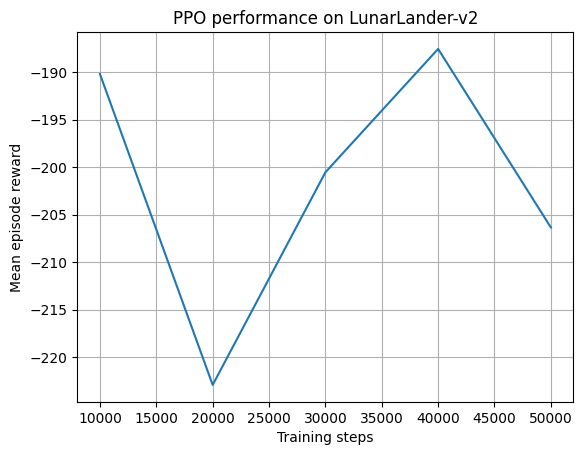

In [ ]:
plt.plot(timesteps, mean_rewards)
plt.xlabel("Training steps")
plt.ylabel("Mean episode reward")
plt.title("PPO performance on LunarLander-v2")
plt.grid()
plt.show()

# The learning curve shows how the mean episode reward evolves
# as the number of training steps increases.
# An upward trend indicates successful learning.

